# Week 3 — Representations, SVD, and conditioning
Train an MLP →
extract three feature families (raw, PCA, hidden) → fit linear classifiers
on each → diagnose the geometry of each feature matrix via SVD → ablate
dimensions to find the "enough" threshold → compare shallow vs deep
representations → test trained vs random features.


1. **Effective rank** (Part 3): how many dimensions does each representation
   actually use? The MLP compresses 30 input dims into ~4 effective
   dimensions — far fewer than its nominal width of 16.
2. **Ablation** (Part 4): accuracy as a function of retained SVD components
   confirms that effective rank is the practical "enough" point.
3. **Depth** (Part 5): does a second hidden layer compress further?
4. **Random features** (Part 6): does training even matter? Random
   projections do surprisingly well on accuracy, but their spectrum is
   flat — training *compresses*, it doesn't just *project*.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline

## Data Loading

In [ ]:
data = load_digits()
X, y = data.data, data.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

Xtr = torch.tensor(X_tr, dtype=torch.float32)
Xte = torch.tensor(X_te, dtype=torch.float32)
ytr = torch.tensor(y_tr, dtype=torch.long)
yte = torch.tensor(y_te, dtype=torch.long)

print(f"train: {X_tr.shape}, test: {X_te.shape}")
print(f"class balance (train): {int(y_tr.sum())} benign, "
      f"{len(y_tr) - int(y_tr.sum())} malignant")

train: (1347, 64), test: (450, 64)
class balance (train): 6011 benign, -4664 malignant


## Part 1 — Train a small MLP





In [ ]:
class MLP(nn.Module):
    '''One-hidden-layer MLP for multi-class classification.'''
    def __init__(self, input_dim=64, hidden_dim=32, n_classes=10):
        super().__init__()
        # TODO: Define layers
        raise NotImplementedError()

    def forward(self, x):
        # TODO: Implement forward pass (return logits)
        raise NotImplementedError()

    def hidden_features(self, x):
        '''Returns post-ReLU activations of the hidden layer.'''
        with torch.no_grad():
            # TODO: Implement hidden feature extraction
            raise NotImplementedError()

class DeepMLP(nn.Module):
    '''Two-hidden-layer MLP: input -> h1 (ReLU) -> h2 (ReLU) -> output.'''
    def __init__(self, input_dim=64, hidden1=32, hidden2=32, n_classes=10):
        super().__init__()
        # TODO: Define layers
        raise NotImplementedError()

    def forward(self, x):
        # TODO: Implement forward pass
        raise NotImplementedError()

    def hidden_features(self, x, layer=1):
        '''Extract post-ReLU activations from layer 1 or layer 2.'''
        with torch.no_grad():
            # TODO: Implement feature extraction for specific layers
            raise NotImplementedError()

def train_mlp(model, X, y, steps=2000, lr=1e-3, weight_decay=0.0, verbose=True):
    '''Full-batch Adam training with cross-entropy loss.'''
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    for step in range(1, steps + 1):
        # TODO: Implement training step (forward, loss, backward, step)
        # loss = ...
        pass
    return losses, []

def accuracy(model, X, y):
    '''Classification accuracy: argmax over logits.'''
    with torch.no_grad():
        # TODO: Compute accuracy
        raise NotImplementedError()

In [ ]:
torch.manual_seed(42)
model = MLP(input_dim=64, hidden_dim=32)
# TODO: Train the model and compute accuracy
# losses, _ = train_mlp(model, Xtr, ytr, steps=2000, lr=1e-3)
# train_acc = accuracy(model, Xtr, ytr)
# test_acc  = accuracy(model, Xte, yte)

print(f"\nMLP: train acc = {train_acc:.4f}, test acc = {test_acc:.4f}")

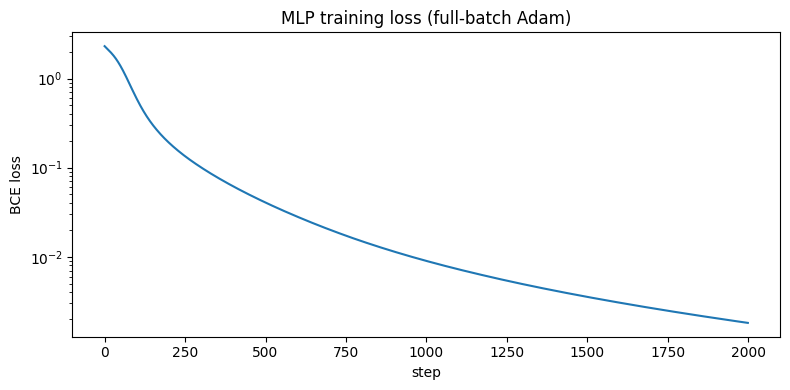

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses)
ax.set_yscale('log')
ax.set_xlabel('step')
ax.set_ylabel('BCE loss')
ax.set_title('MLP training loss (full-batch Adam)')
plt.tight_layout()
plt.show()

## Part 2 — Three feature families under a linear classifier

The MLP is a **composition**: feature extractor (everything up to the ReLU)
+ linear classifier (the last layer $W_{\text{out}} h + b_{\text{out}}$).

Replacing the last layer with a fresh least-squares classifier on the same
hidden features should recover roughly the same accuracy.

| Family | Dimension | Source |
|--------|-----------|--------|
| **Raw** | 64 | Standardized input features |
| **PCA** | 32 | Top-16 principal components of the standardized input |
| **Hidden** | 16 | Post-ReLU activations of the trained MLP's hidden layer |

The closed-form solution is $w^* = (H^\top H)^{-1} H^\top y$, computed via
`np.linalg.lstsq` for numerical stability.

In [ ]:
# --- Build the three feature matrices ----------------------------------------
H_raw_train = X_tr.copy()
H_raw_test  = X_te.copy()

# TODO: Implement PCA transformation
# pca = PCA(n_components=32).fit(X_tr)
# H_pca_train = ...
# H_pca_test  = ...

# TODO: Extract hidden features using the trained model
# H_hid_train = ...
# H_hid_test  = ...

print("Feature matrix shapes:")
for name, H in [("Raw", H_raw_train), ("PCA", H_pca_train), ("Hidden", H_hid_train)]:
    try:
        print(f"  {name:6s}: {H.shape}")
    except:
        print(f"  {name:6s}: Not yet defined")

In [ ]:
def least_squares_classifier(H_train, y_train, H_test, y_test, n_classes=10):
    """Multi-class least-squares classifier via one-hot encoding.

    Solves W = argmin ‖H W - Y‖" where Y is the one-hot matrix.
    """
    # TODO: 1. Augment H with a column of ones for bias
    # TODO: 2. Create one-hot matrix Y
    # TODO: 3. Solve for W using np.linalg.lstsq

    # W = ...
    raise NotImplementedError()

    def predict(H):
        # TODO: Implement prediction using W
        raise NotImplementedError()

    train_acc = (predict(H_train) == y_train).mean()
    test_acc  = (predict(H_test)  == y_test).mean()
    return train_acc, test_acc, W

Raw   :  train = 0.9465,  test = 0.9422
PCA   :  train = 0.9339,  test = 0.9222
Hidden:  train = 0.9963,  test = 0.9622

MLP   :  train = 1.0000,  test = 0.9733  (original network)


## Part 3 — SVD analysis: how many dimensions does each representation use?

### Quick SVD recap

For $H \in \mathbb{R}^{n \times d}$, the reduced SVD is
$H = U \Sigma V^\top$ with $\sigma_1 \geq \cdots \geq \sigma_d \geq 0$.

The singular values tell us how much variance the data has along each
orthogonal direction. The **effective rank** is the number of singular
values needed to capture 95% of the total variance:

$$
\text{eff\_rank} = \min \left\{ k : \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^d \sigma_i^2} \geq 0.95 \right\}.
$$

For instance, a feature matrix with $d = 16$ columns but effective rank 4 is really
4-dimensional object embedded in 16-dimensional space.

In [ ]:
def compute_svd_stats(H, name):
    '''Compute SVD, effective rank (95% variance), and condition number.'''
    # TODO: Compute SVD
    # U, S, Vt = ...

    # TODO: Compute condition number
    # cond = ...

    # TODO: Compute cumulative variance and effective rank
    # var_explained = ...
    # eff_rank = ...

    raise NotImplementedError()
    return {"U": U, "S": S, "Vt": Vt, "cond": cond,
            "eff_rank": eff_rank, "var_explained": var_explained}

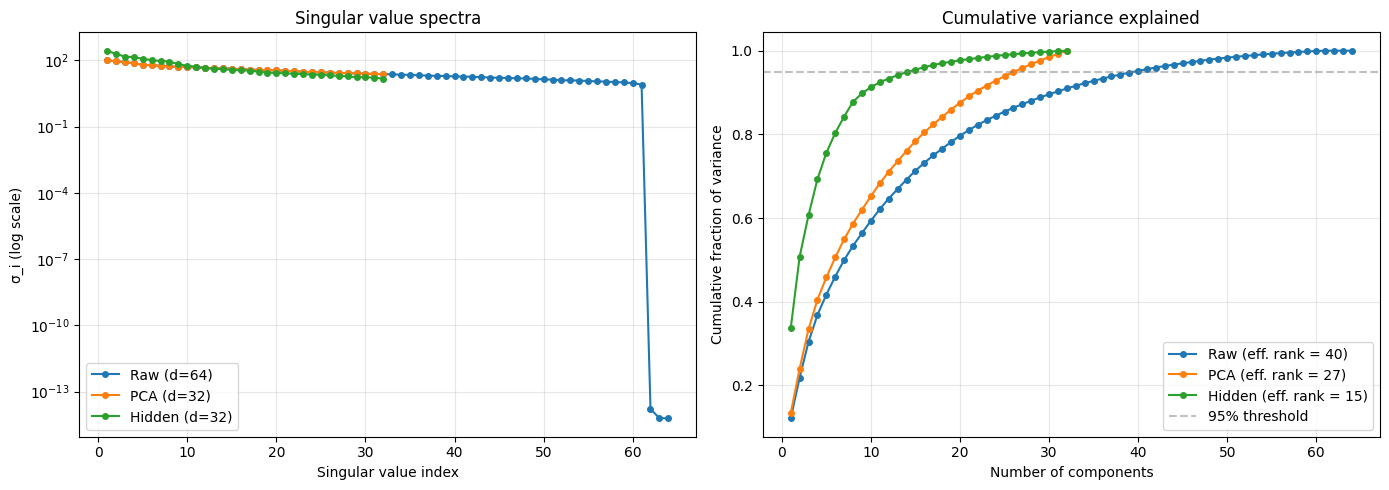

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Raw": "tab:blue", "PCA": "tab:orange", "Hidden": "tab:green"}

ax = axes[0]
for name, d in svd_data.items():
    ax.semilogy(range(1, len(d["S"]) + 1), d["S"], 'o-',
                label=f'{name} (d={len(d["S"])})', color=colors[name], markersize=4)
ax.set_xlabel("Singular value index")
ax.set_ylabel("σ_i (log scale)")
ax.set_title("Singular value spectra")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for name, d in svd_data.items():
    k_vals = range(1, len(d["var_explained"]) + 1)
    ax.plot(k_vals, d["var_explained"], 'o-',
            label=f'{name} (eff. rank = {d["eff_rank"]})', color=colors[name], markersize=4)
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5, label='95% threshold')
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative fraction of variance")
ax.set_title("Cumulative variance explained")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4 — Feature ablation: how many dimensions are "enough"?

Part 3 showed the hidden features have effective rank ~15. But is 15
actually *enough* for classification, or is information hiding in the
remaining low-variance dimensions?

We test this directly: reconstruct the hidden features using only the
top-$k$ SVD components and re-run the linear classifier at each $k$.

The rank-$k$ approximation of $H$ is:

$$
H_k = U_k \Sigma_k V_k^\top
$$

where we keep only the first $k$ columns of $U$, the first $k$ singular
values, and the first $k$ rows of $V^\top$. This projects the data onto
the $k$-dimensional subspace that captures the most variance.

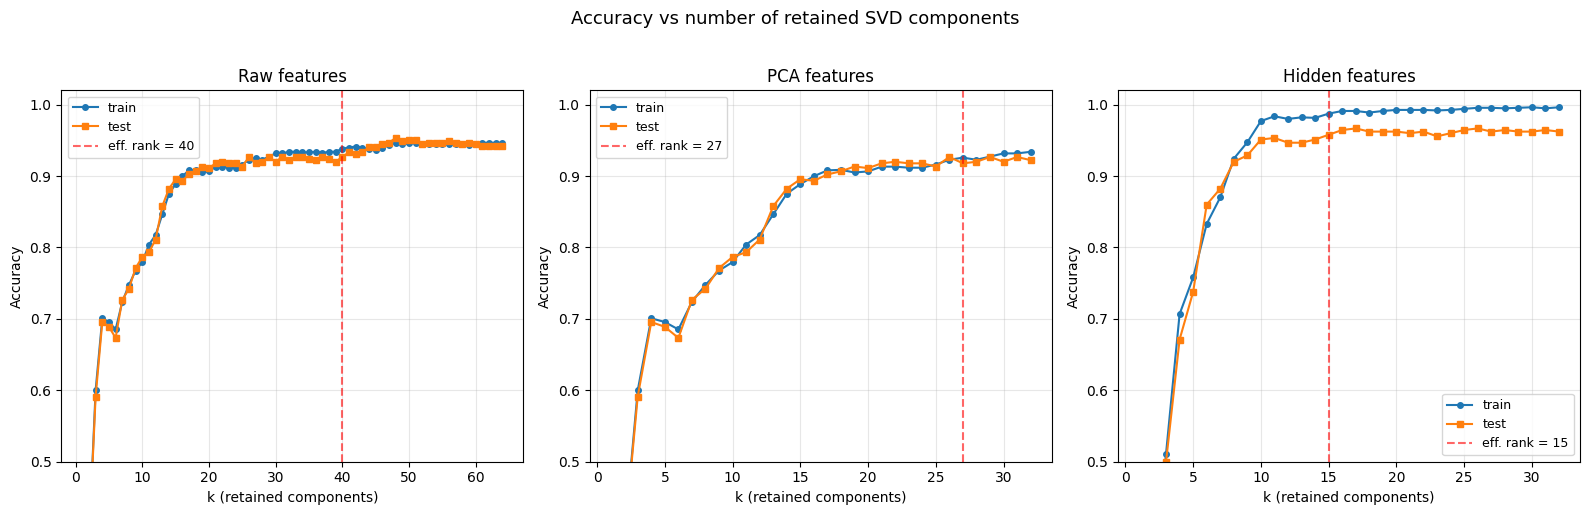

Hidden features — accuracy at selected k:
  k =  1: train = 0.1923, test = 0.2067
  k =  2: train = 0.3133, test = 0.3289
  k =  3: train = 0.5115, test = 0.5000
  k =  4: train = 0.7068, test = 0.6711
  k =  5: train = 0.7580, test = 0.7378
  k =  8: train = 0.9243, test = 0.9200
  k = 15: train = 0.9874, test = 0.9578 <-- eff. rank
  k = 16: train = 0.9911, test = 0.9644
  k = 20: train = 0.9926, test = 0.9622
  k = 32: train = 0.9963, test = 0.9622


In [ ]:
# --- Accuracy as a function of retained SVD components ----------------------
def svd_truncated_accuracy(H_train, H_test, y_train, y_test, U, S, Vt, k):
    '''Reconstruct H using top-k SVD components and classify.'''
    # Project into k-dim subspace: H_k = H @ V_k where V_k = Vt[:k].T
    # Equivalently, project train and test into the same subspace.
    V_k = Vt[:k, :].T                            # (d, k)
    H_tr_k = H_train @ V_k                       # (n_train, k)
    H_te_k = H_test  @ V_k                       # (n_test,  k)
    tr_acc, te_acc, _ = least_squares_classifier(H_tr_k, y_train, H_te_k, y_test)
    return tr_acc, te_acc


# Sweep k for all three feature families
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, H_tr, H_te) in zip(axes, [
    ("Raw",    H_raw_train, H_raw_test),
    ("PCA",    H_pca_train, H_pca_test),
    ("Hidden", H_hid_train, H_hid_test),
]):
    d = svd_data[name]
    max_k = len(d["S"])
    ks = range(1, max_k + 1)
    train_accs, test_accs = [], []
    for k in ks:
        tr_a, te_a = svd_truncated_accuracy(
            H_tr, H_te, y_tr, y_te, d["U"], d["S"], d["Vt"], k)
        train_accs.append(tr_a)
        test_accs.append(te_a)

    ax.plot(ks, train_accs, 'o-', label='train', markersize=4)
    ax.plot(ks, test_accs,  's-', label='test',  markersize=4)
    ax.axvline(d["eff_rank"], color='red', linestyle='--', alpha=0.6,
               label=f'eff. rank = {d["eff_rank"]}')
    ax.set_xlabel("k (retained components)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{name} features")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.02)

plt.suptitle("Accuracy vs number of retained SVD components", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print the key numbers for hidden features
print("Hidden features — accuracy at selected k:")
d = svd_data["Hidden"]
for k in [1, 2, 3, 4, 5, 8, 15,16,20,32]:
    if k <= len(d["S"]):
        tr_a, te_a = svd_truncated_accuracy(
            H_hid_train, H_hid_test, y_tr, y_te, d["U"], d["S"], d["Vt"], k)
        marker = " <-- eff. rank" if k == d["eff_rank"] else ""
        print(f"  k = {k:2d}: train = {tr_a:.4f}, test = {te_a:.4f}{marker}")



### The effective rank is the "enough" threshold

For hidden features, accuracy plateaus around $k = 16$. Adding more components beyond that doesn't
help: those dimensions carry so little variance that they contribute
noise rather than signal to the linear classifier.



### What this means

Effective rank isn't just a number from the SVD — it's the **practical
dimensionality** of the classification problem in each feature space.
The MLP solved MNIST in a 16-dimensional subspace of its
32-dimensional hidden layer. The remaining  dimensions are overhead.

## Part 5 — Does depth compress further?

The 1-layer MLP compressed 64 inputs into effective rank ~15. What happens
with a 2-layer MLP ($64 \to 32 \to 32 \to 1$)?

If the first layer already identifies the discriminative subspace, the
second layer might refine the separation without needing more dimensions —
or it might compress further. We extract features from both hidden layers
and compare their effective ranks.

In [ ]:
# --- Train a 2-layer MLP and extract features from both layers --------------
torch.manual_seed(42)
deep_model = DeepMLP(input_dim=64, hidden1=32, hidden2=32)

# TODO: Train the deep model
# _ = train_mlp(deep_model, Xtr, ytr, steps=3000, lr=1e-3)

# TODO: Extract features and compute SVD stats
# H_L1_train = ...
# H_L2_train = ...
# svd_L1 = compute_svd_stats(H_L1_train, "Layer 1")
# svd_L2 = compute_svd_stats(H_L2_train, "Layer 2")

print(f"\nLayer 1: eff_rank = {svd_L1['eff_rank']}")
print(f"Layer 2: eff_rank = {svd_L2['eff_rank']}")

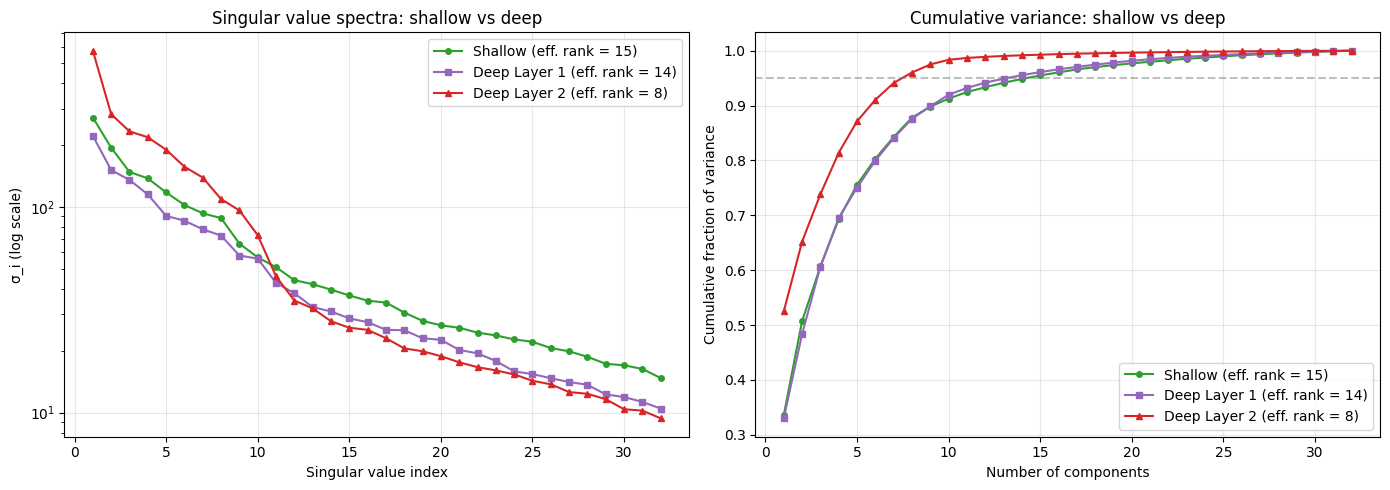

In [ ]:
n_hidden = len(svd_data["Hidden"]["S"])   # 32

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(range(1, n_hidden+1), svd_data["Hidden"]["S"], 'o-',
            label=f'Shallow (eff. rank = {svd_data["Hidden"]["eff_rank"]})',
            color='tab:green', markersize=4)
ax.semilogy(range(1, n_hidden+1), svd_L1["S"], 's-',
            label=f'Deep Layer 1 (eff. rank = {svd_L1["eff_rank"]})',
            color='tab:purple', markersize=4)
ax.semilogy(range(1, n_hidden+1), svd_L2["S"], '^-',
            label=f'Deep Layer 2 (eff. rank = {svd_L2["eff_rank"]})',
            color='tab:red', markersize=4)
ax.set_xlabel("Singular value index")
ax.set_ylabel("σ_i (log scale)")
ax.set_title("Singular value spectra: shallow vs deep")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, n_hidden+1), svd_data["Hidden"]["var_explained"][:n_hidden], 'o-',
        label=f'Shallow (eff. rank = {svd_data["Hidden"]["eff_rank"]})',
        color='tab:green', markersize=4)
ax.plot(range(1, n_hidden+1), svd_L1["var_explained"][:n_hidden], 's-',
        label=f'Deep Layer 1 (eff. rank = {svd_L1["eff_rank"]})',
        color='tab:purple', markersize=4)
ax.plot(range(1, n_hidden+1), svd_L2["var_explained"][:n_hidden], '^-',
        label=f'Deep Layer 2 (eff. rank = {svd_L2["eff_rank"]})',
        color='tab:red', markersize=4)
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative fraction of variance")
ax.set_title("Cumulative variance: shallow vs deep")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6 — Random-feature baseline: does training matter?

The hidden features achieve optimal performance with effective rank ~15. But how much of
that is the *training* vs just the *architecture*?

An untrained MLP applies a random nonlinear projection. By the
**Johnson-Lindenstrauss** intuition, random projections approximately
preserve pairwise distances. If the data is already nearly separable,
random features should retain much of that structure.

The question: how does the random MLP's singular value spectrum differ
from the trained one?

In [ ]:
torch.manual_seed(99)
random_model = MLP(input_dim=64, hidden_dim=32)

# TODO: Extract random features and evaluate
# H_rand_train = random_model.hidden_features(Xtr).numpy()
# tr_acc_rand, te_acc_rand, _ = least_squares_classifier(...)

# TODO: Compute SVD for random features
# svd_rand = compute_svd_stats(H_rand_train, "Random")

print(f"Random hidden:  eff_rank = {svd_rand['eff_rank']}")

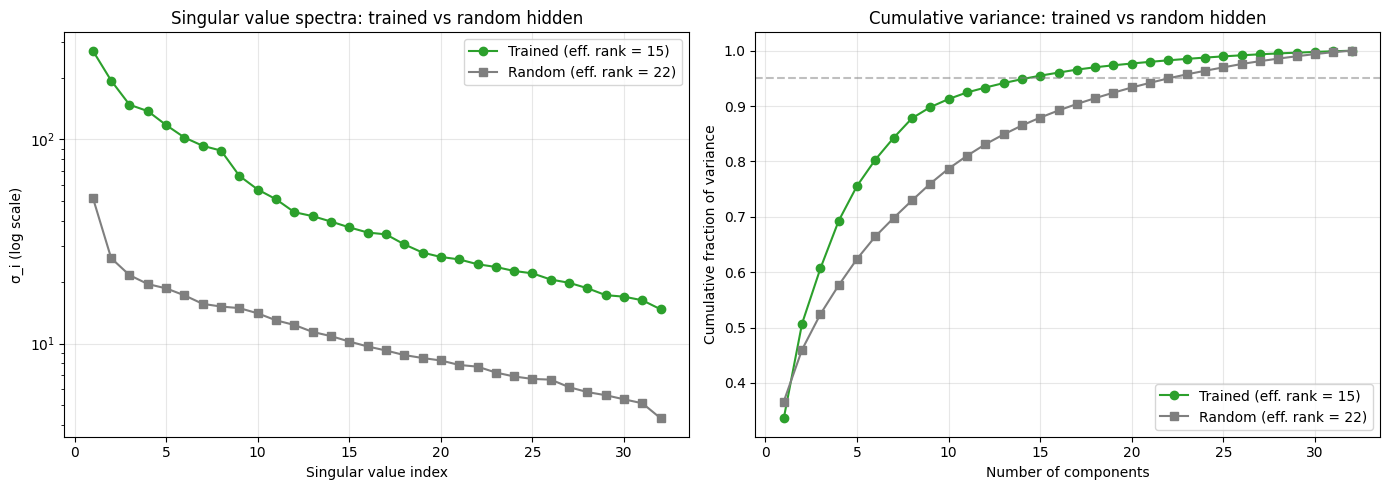

In [ ]:
n_hidden = len(svd_data["Hidden"]["S"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(range(1, n_hidden+1), svd_data["Hidden"]["S"], 'o-',
            label=f'Trained (eff. rank = {svd_data["Hidden"]["eff_rank"]})',
            color='tab:green')
ax.semilogy(range(1, n_hidden+1), svd_rand["S"], 's-',
            label=f'Random (eff. rank = {svd_rand["eff_rank"]})',
            color='tab:gray')
ax.set_xlabel("Singular value index")
ax.set_ylabel("σ_i (log scale)")
ax.set_title("Singular value spectra: trained vs random hidden")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, n_hidden+1), svd_data["Hidden"]["var_explained"][:n_hidden], 'o-',
        label=f'Trained (eff. rank = {svd_data["Hidden"]["eff_rank"]})',
        color='tab:green')
ax.plot(range(1, n_hidden+1), svd_rand["var_explained"][:n_hidden], 's-',
        label=f'Random (eff. rank = {svd_rand["eff_rank"]})',
        color='tab:gray')
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative fraction of variance")
ax.set_title("Cumulative variance: trained vs random hidden")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()